<a href="https://colab.research.google.com/github/Sujana555/ML-Predict-Student-Grade/blob/main/PredictStudentGrade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Steps to follow
# Get the dataset
# Visualize the data
# Fit a linear Regression Model
# Predict Unseen data
# Evaluate the model


In [2]:
# get the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Import Libraries
import pandas as pd
# LIbraries for visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Data Exploration
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML-Projects/Project1: PredictStudentGrade/student-mat.csv', sep=";")
# df

# Data cleaning
df['G1'] = pd.to_numeric(df['G1'])
df['G2'] = pd.to_numeric(df['G2'])
print(df['G3'])

0       6
1       6
2      10
3      15
4      10
       ..
390     9
391    16
392     7
393    10
394     9
Name: G3, Length: 395, dtype: int64


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
# TEMP CELL
# df_numeric.columns
target = df.G3
df_object.corrwith(target)['higher']

# for cols in df_numeric:
#   df_numeric[cols] = pd.to_numeric(df_numeric[cols])

# df_numeric.dtypes

0       6
1       6
2      10
3      15
4      10
       ..
390     9
391    16
392     7
393    10
394     9
Name: G3, Length: 395, dtype: int64


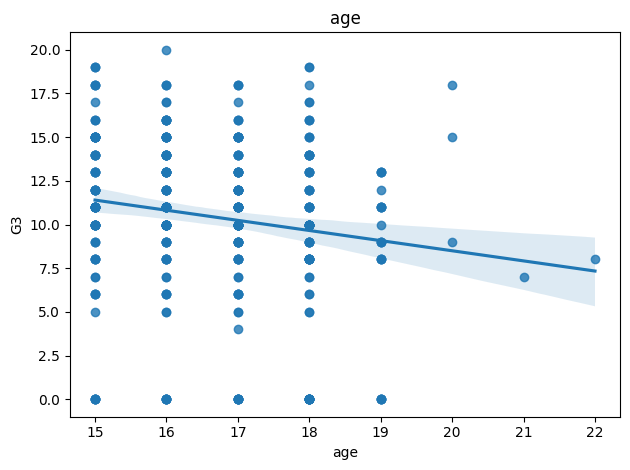

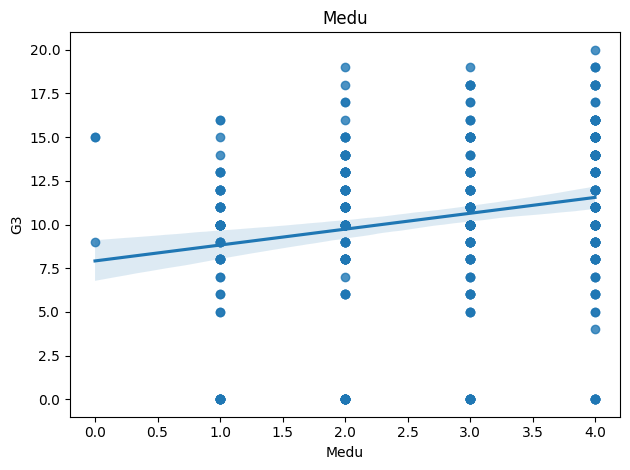

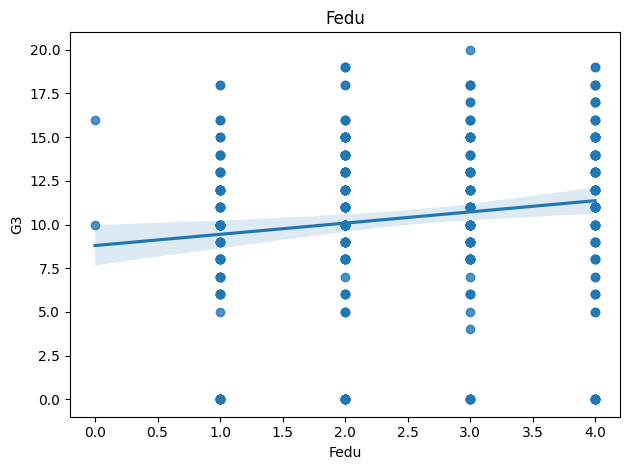

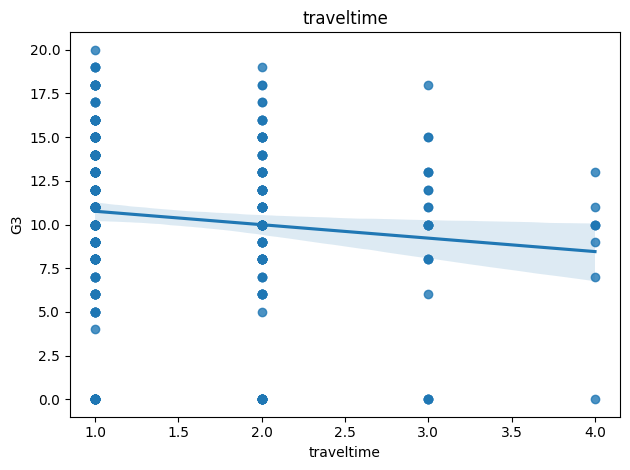

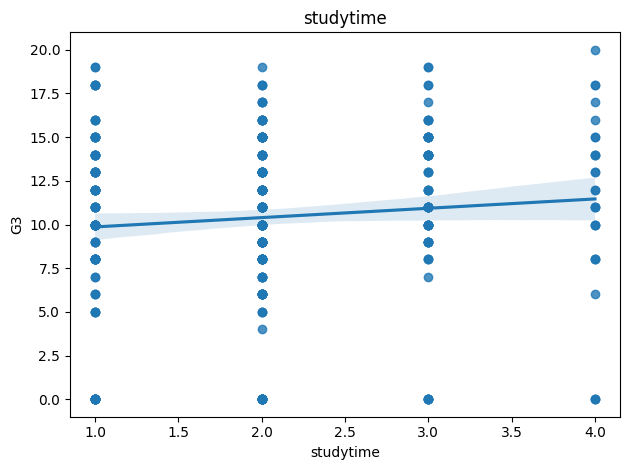

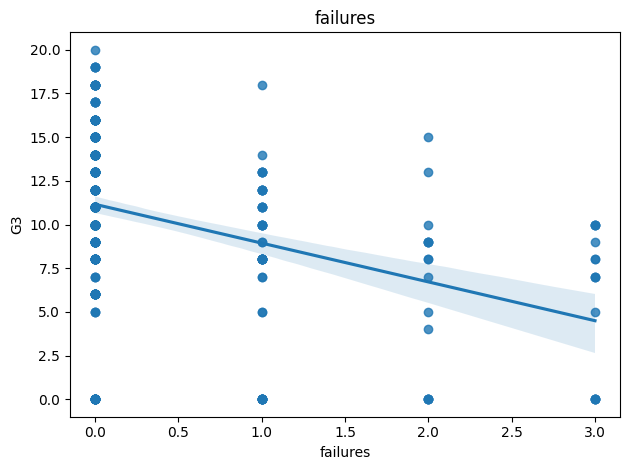

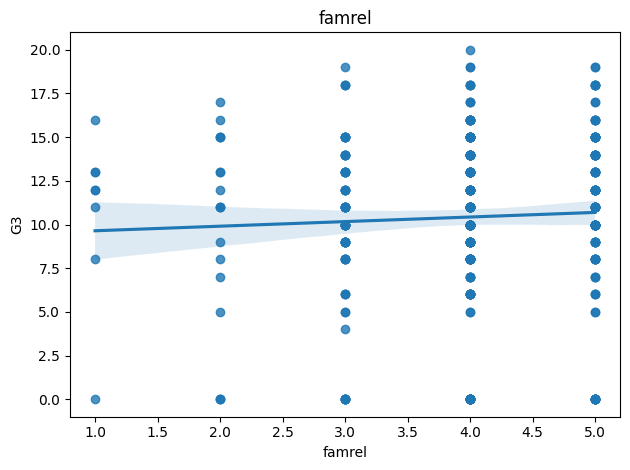

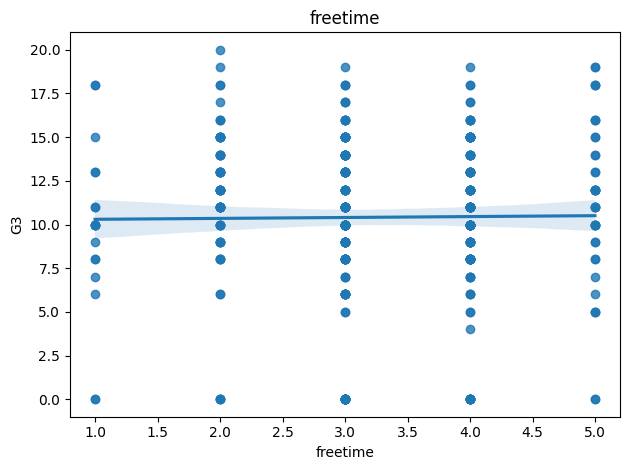

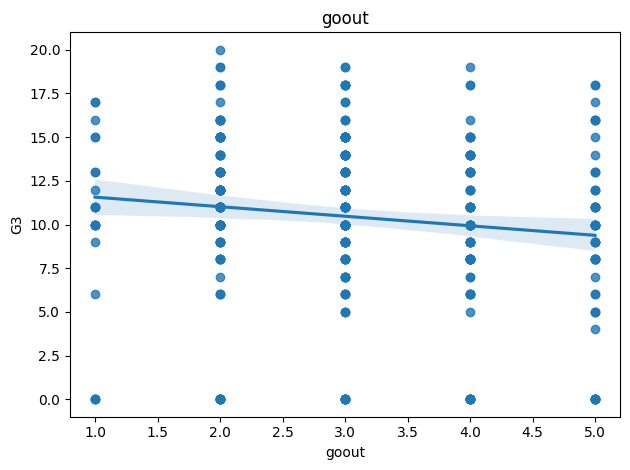

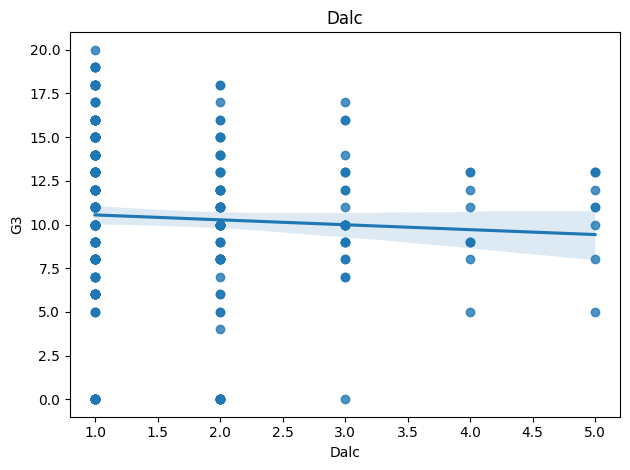

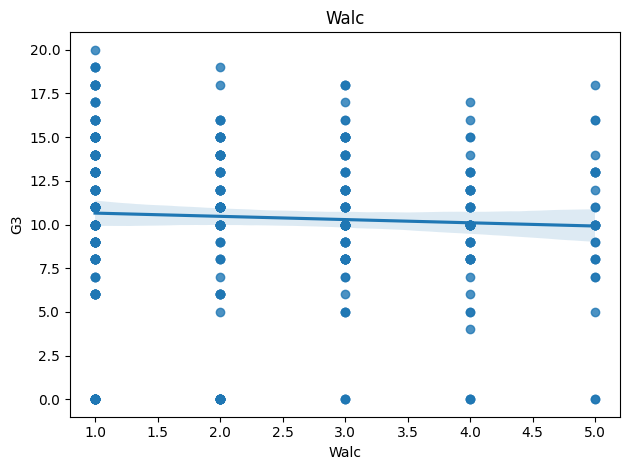

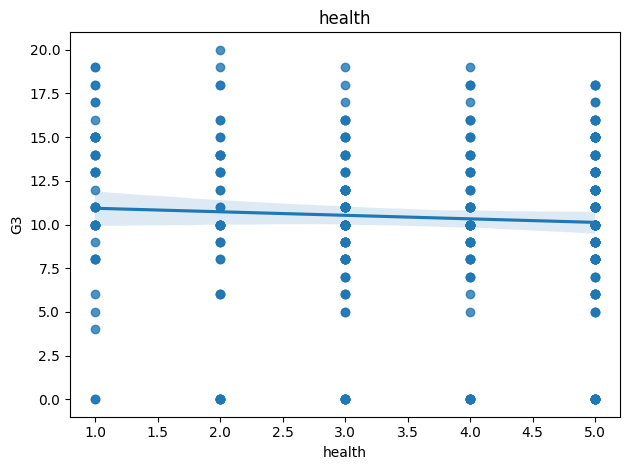

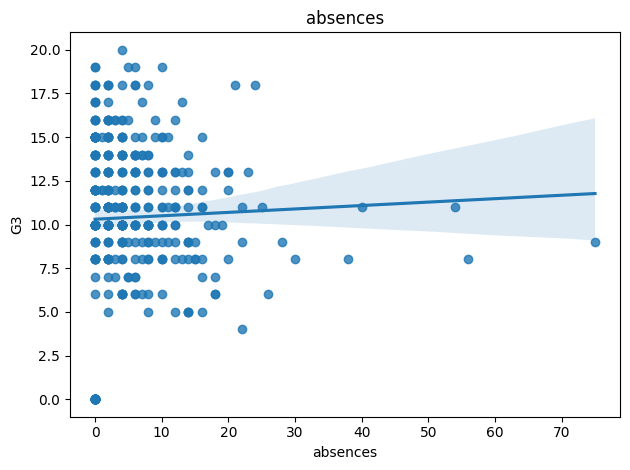

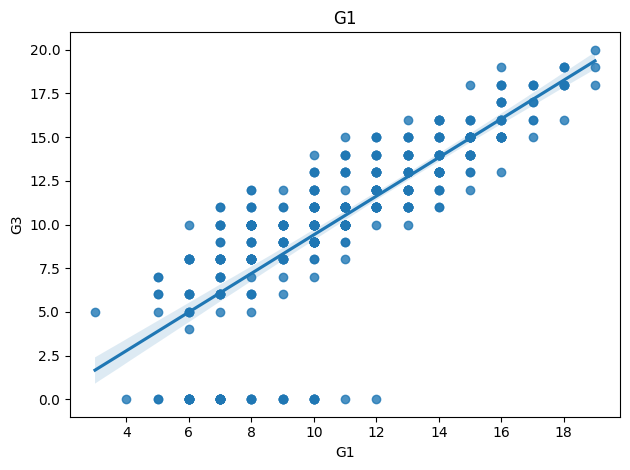

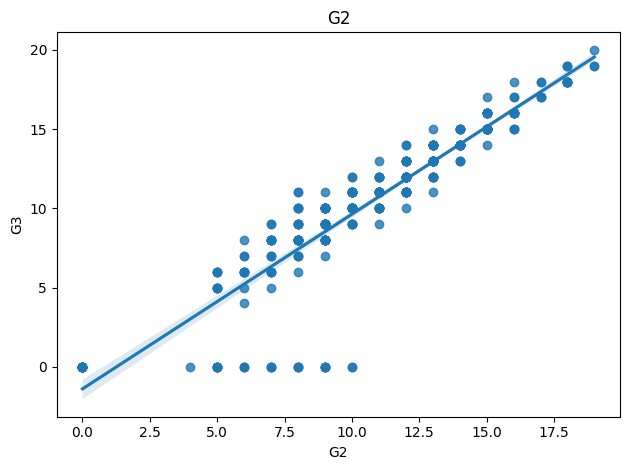

In [14]:
print(df['G3'])
# Seperate G3 from df
target = df.G3

# Seperate the non-numerical variables
df_object = df.select_dtypes(include="object")
# Seperate the numerical variables
df_numeric = df.select_dtypes(include="number")
df_numeric = df_numeric.drop(columns=['G3'])

for col in df_numeric:
  sns.regplot(x=df_numeric[col], y=target, data=df_numeric, label=col)
  plt.title(col)
  plt.ylabel('G3')
  plt.xlabel(col)
  plt.tight_layout()
  plt.show()


In [ ]:
for col in df_object:
    sns.boxplot(x=df[col], y=df['G3'])
    plt.title(col)
    plt.show()

In [ ]:
# Visualize data as a histogram
for column in df:
  sns.histplot(df[column], color='plum', edgecolor="k", linewidth=1)
  plt.show()

In [15]:
# Data CLeaning

# Get rid of any rows with a null value
df = df.dropna()
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [16]:
# Encode object values with numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
  df[col] = le.fit_transform(df[col])

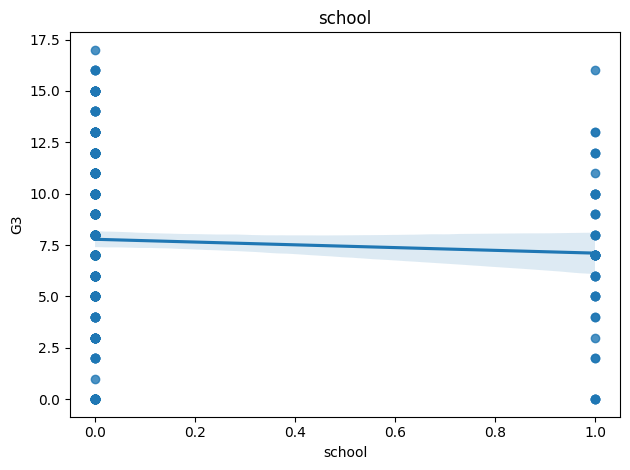

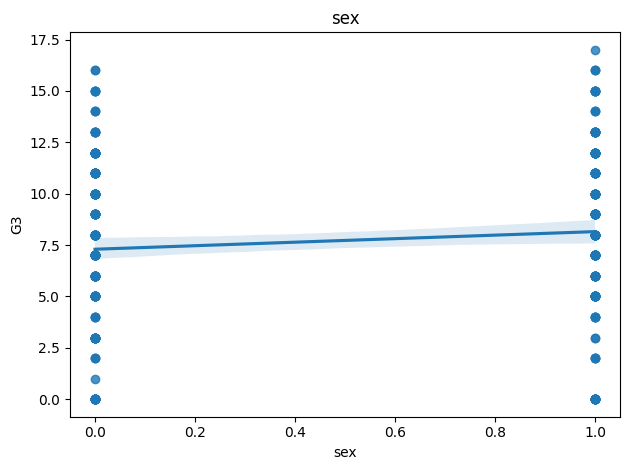

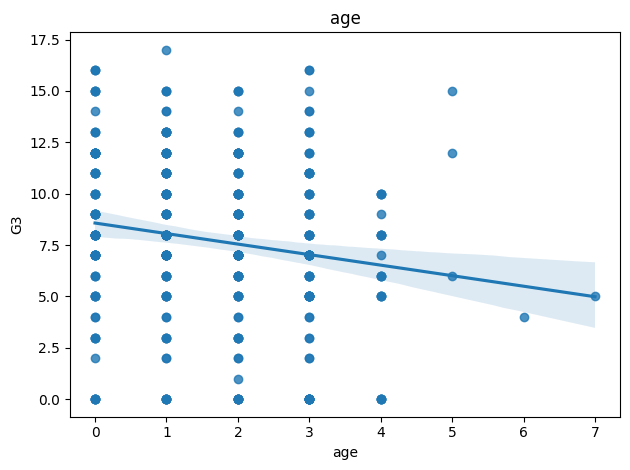

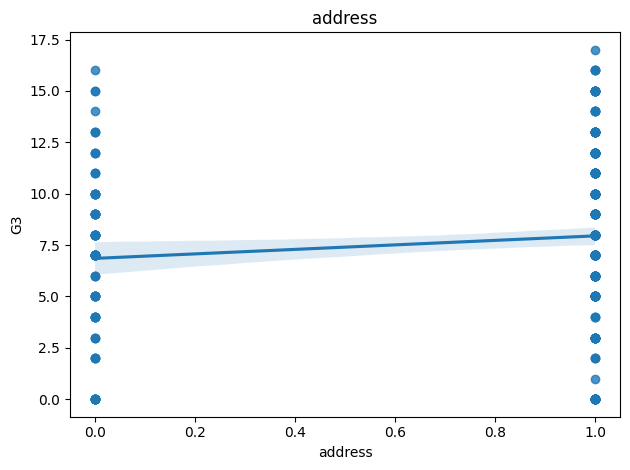

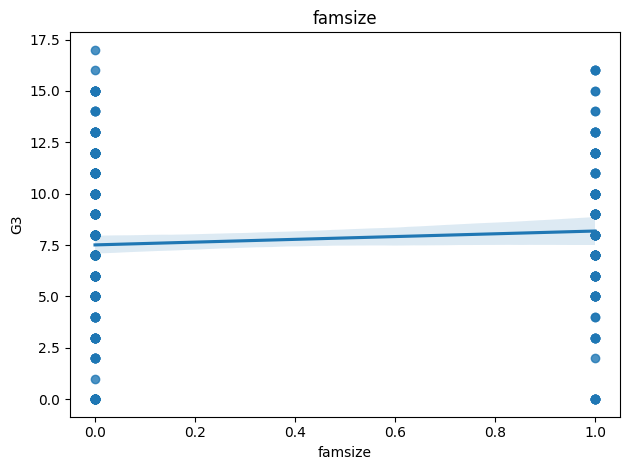

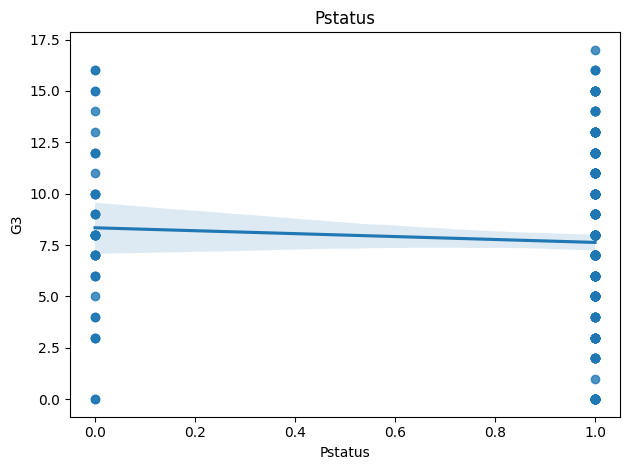

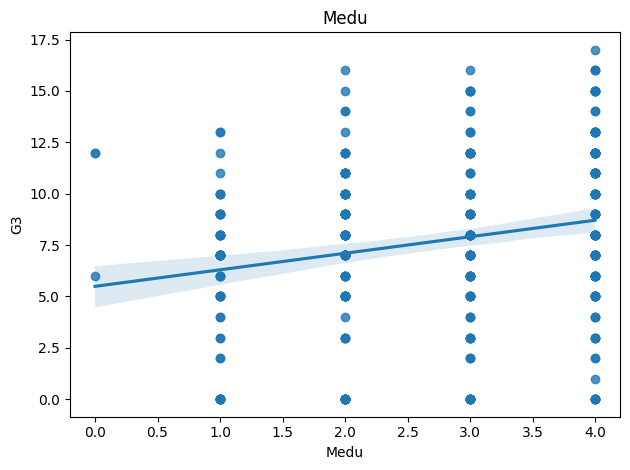

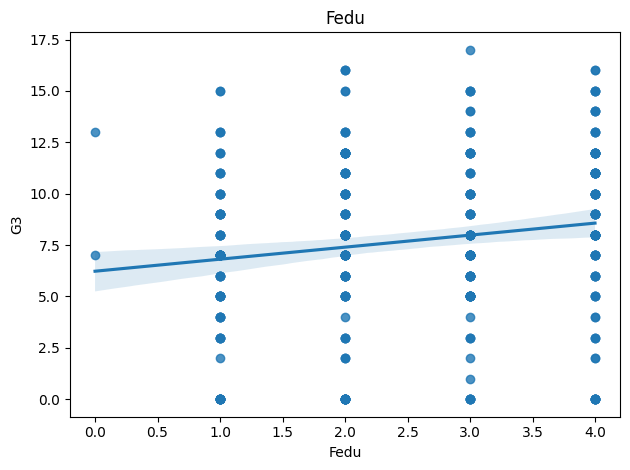

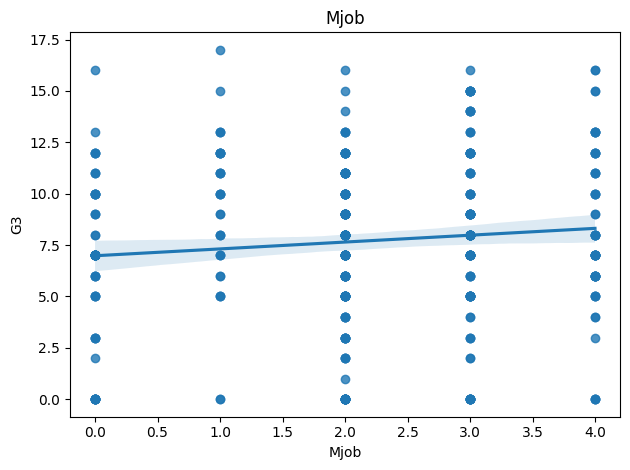

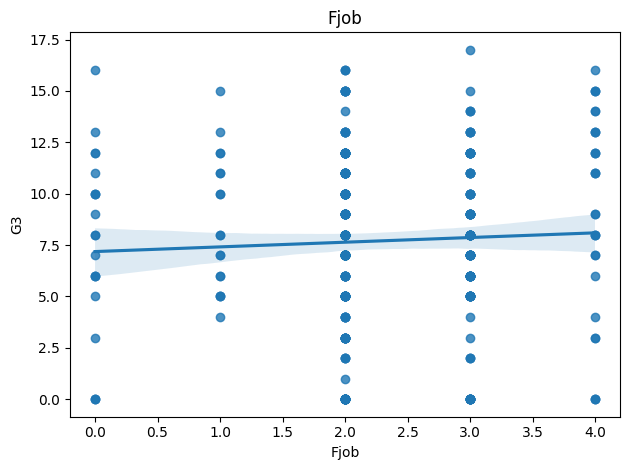

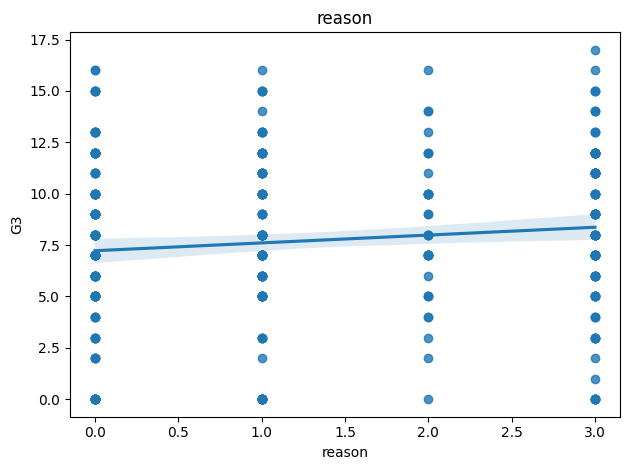

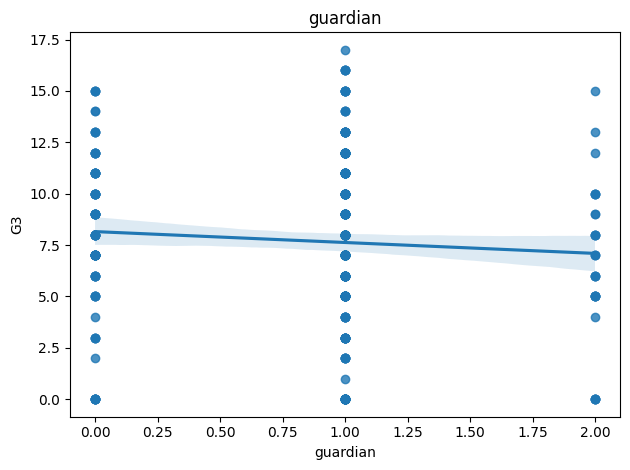

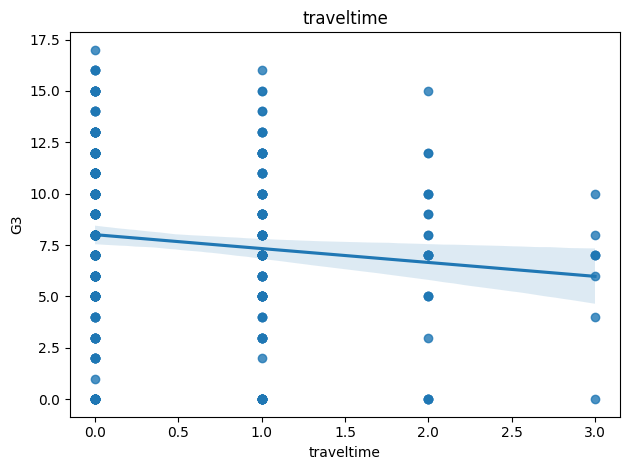

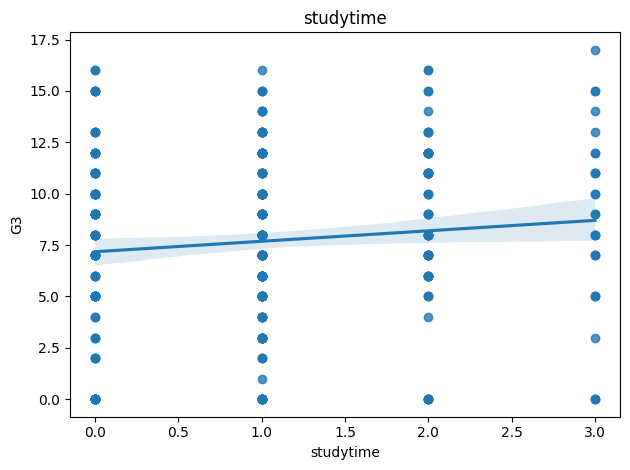

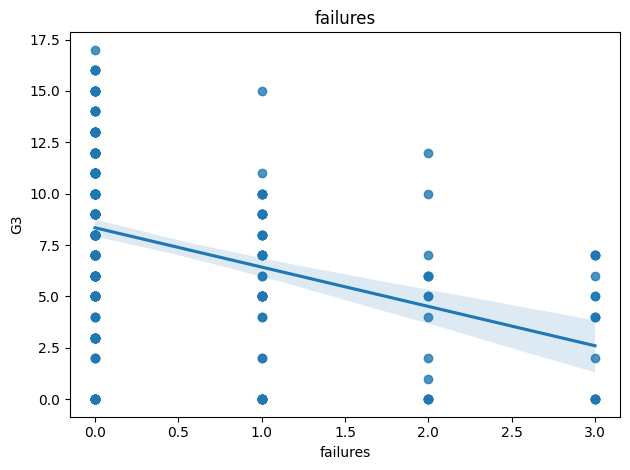

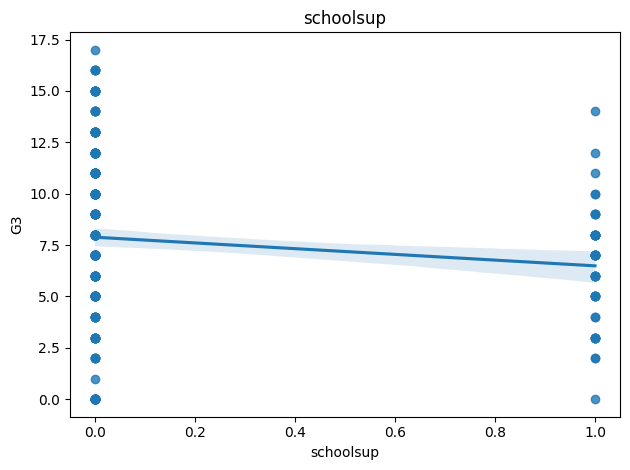

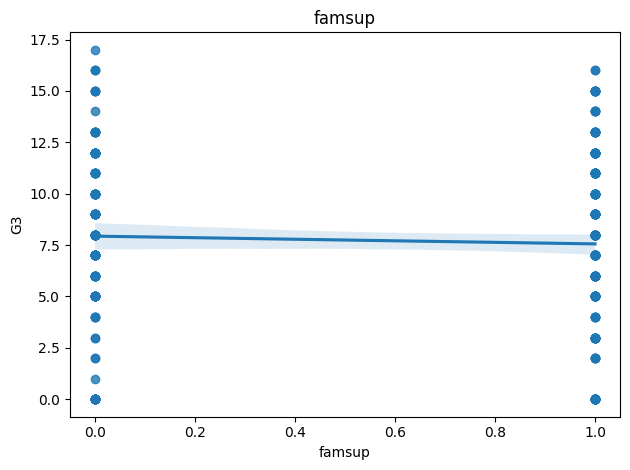

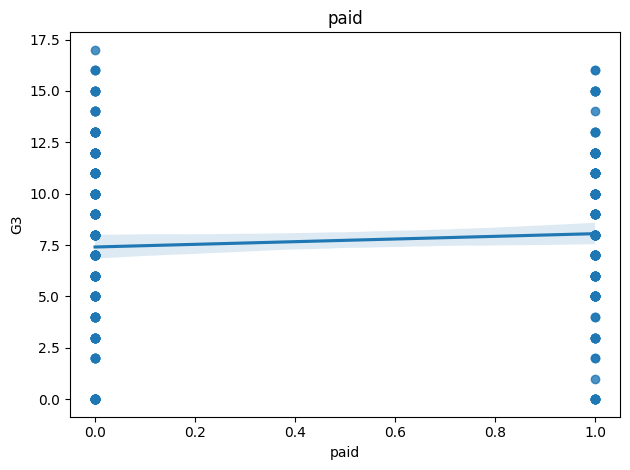

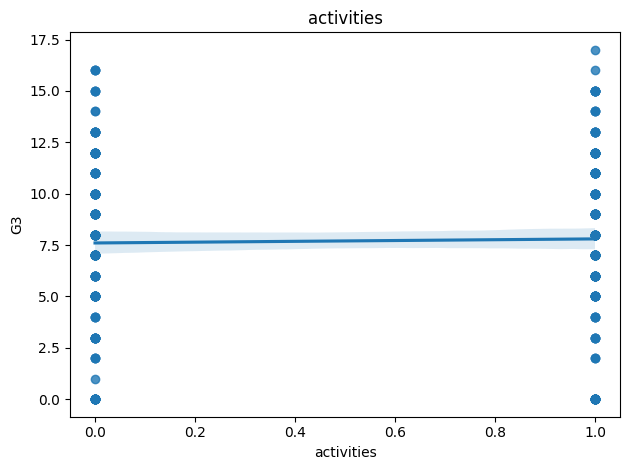

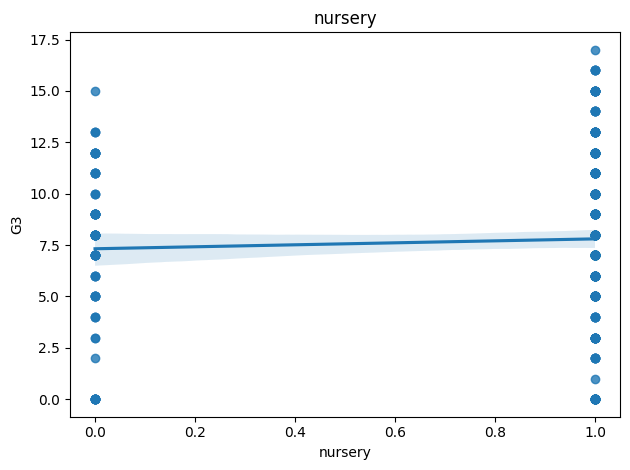

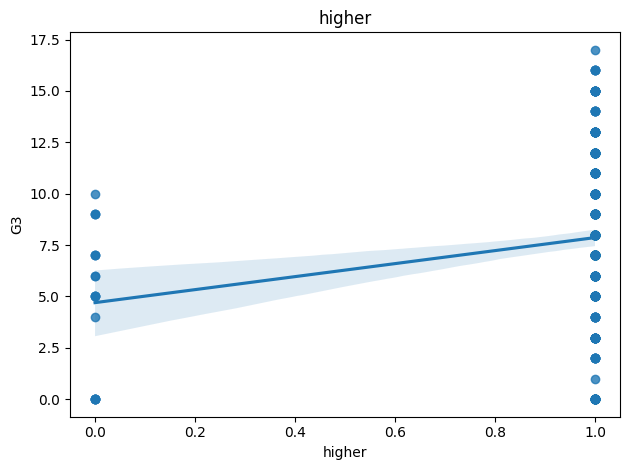

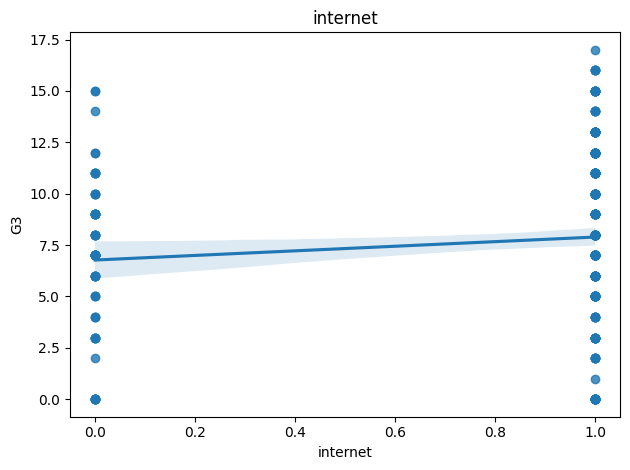

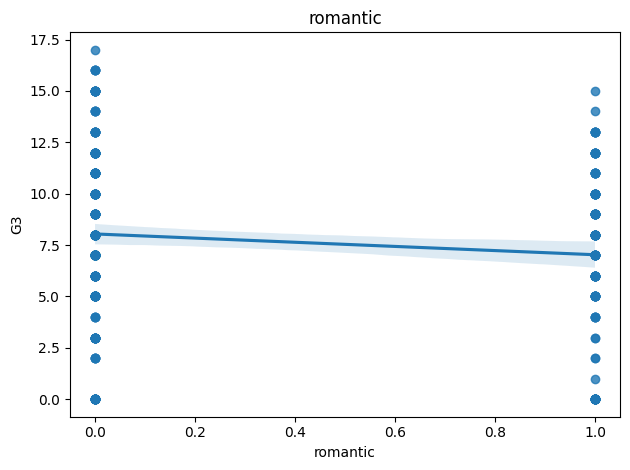

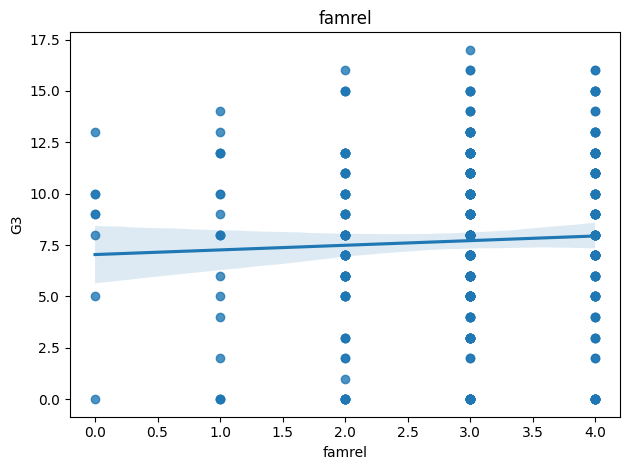

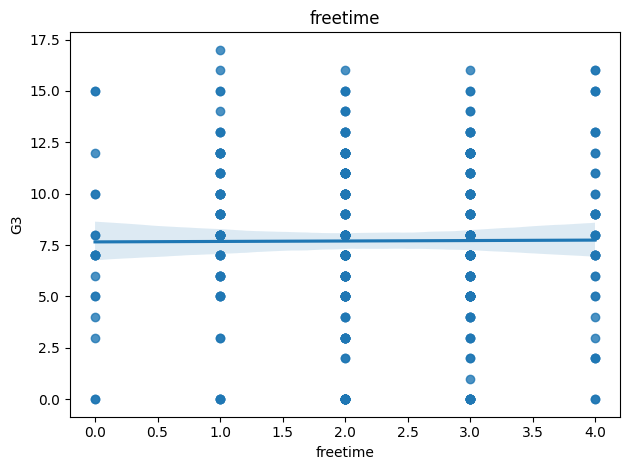

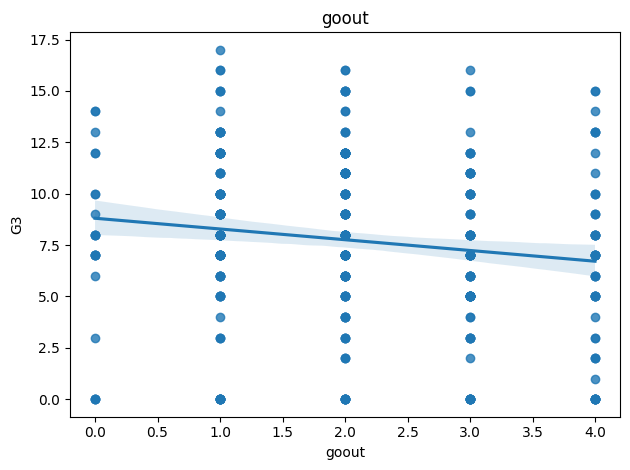

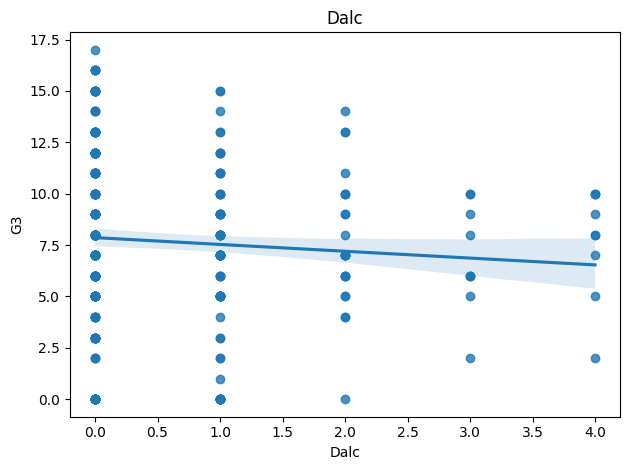

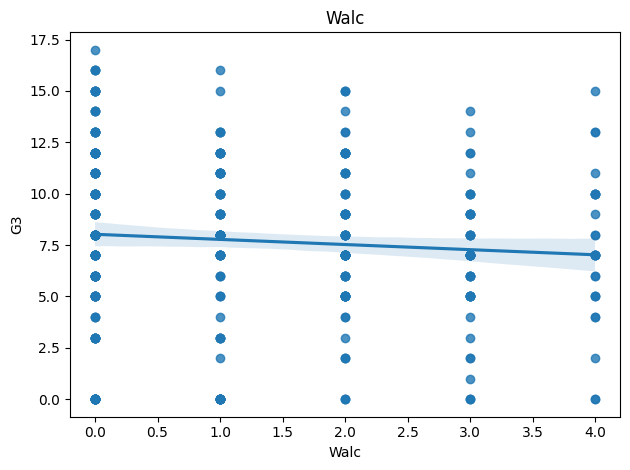

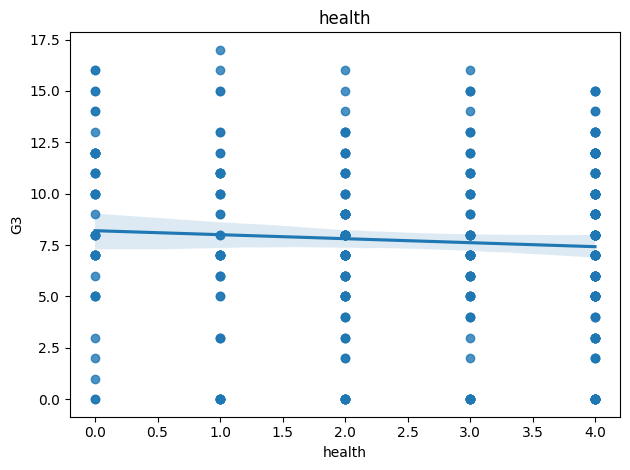

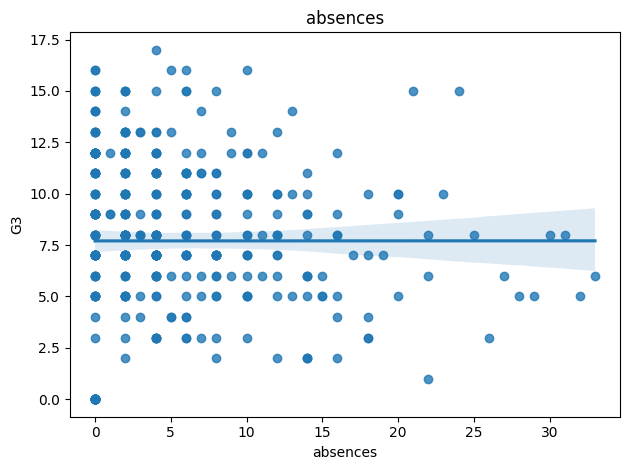

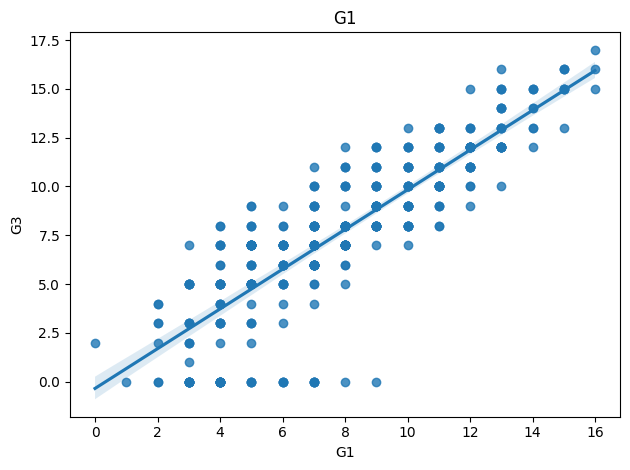

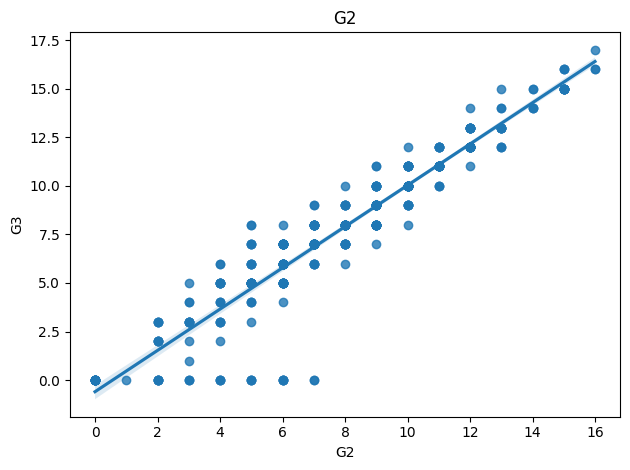

In [17]:
# Putting in a scatterplot again
target = df.G3
df_no_target = df.drop(columns=['G3'])

for col in df_no_target:
  sns.regplot(x=df_no_target[col], y=target, data=df_no_target, label=col)
  plt.title(col)
  plt.ylabel('G3')
  plt.xlabel(col)
  plt.tight_layout()
  plt.show()

In [ ]:
# Find the correlation coeffience for every variable in a sorted order
# Seperate x and y.

corr_coeff = df_no_target.corrwith(target).abs().sort_values(ascending=False)
# Make a feature list with G2 to Fedu
feature_list = corr_coeff.index[:7]
# print(feature_list)
x = df_no_target[feature_list]
y = target
# print(corr_coeff)


In [30]:
# Data Splitting
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=10)
x_train.head()


,G2,G1,failures,Medu,higher,age,Fedu
266,6,6,0,3,1,2,1
352,4,5,1,1,0,3,3
97,6,5,0,2,1,1,1
167,12,11,0,4,1,1,2
280,5,5,0,4,1,2,1


In [33]:
# Train the model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model = lr.fit(x_train, y_train)

In [34]:
print(lr.score(x_test, y_test)) # see how accurate the data is

0.8565690302772074


In [37]:
# Make predictions using x test
predictions = lr.predict(x_test)

Text(0, 0.5, 'Predicted Grade')

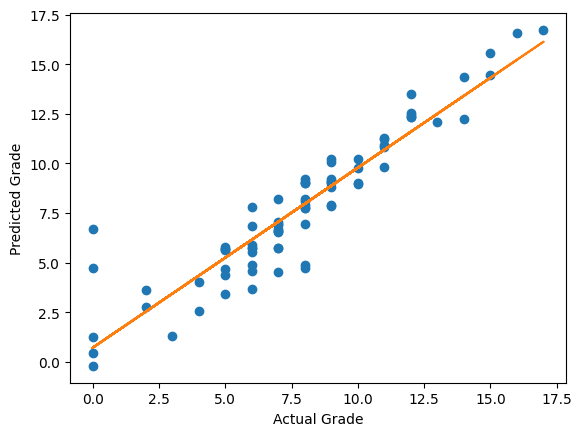

In [38]:
# Plot it

plt.plot(y_test, predictions, 'o')
m, b = np.polyfit(y_test,predictions, 1)
plt.plot(y_test, m*y_test + b)
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")